GPU Programming - Day 1

### Setup

##### GPU Setup

In [1]:
!nvcc --version
!nvidia-smi
!pip install nvcc4jupyter
%load_ext nvcc4jupyter

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
Mon Jul 20 02:15:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8       

##### Google Drive Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### First Kernel - ClaudeCode method of running

In [3]:
%%cuda
#include <cstdio>
__global__ void hello(){ printf("Hello from block %u thread %u\n", blockIdx.x, threadIdx.x); }
int main(){ hello<<<2,2>>>(); cudaDeviceSynchronize(); }

Hello from block 1 thread 0
Hello from block 1 thread 1
Hello from block 0 thread 0
Hello from block 0 thread 1



### GrayScale - PyTorch Integration

In [4]:
from pathlib import Path
import torch
from torchvision.io import read_image, write_png
from torch.utils.cpp_extension import load_inline

import matplotlib.pyplot as plt

In [5]:
def compile_extension(kernel_path, cpp_source, kernel_name, functions):
    cuda_source = Path(kernel_path).read_text()

    # Load the CUDA kernel as a PyTorch extension
    rgb_to_grayscale_extension = load_inline(
        name=kernel_name,
        cpp_sources=cpp_source,
        cuda_sources=cuda_source,
        functions=functions,
        with_cuda=True,
        extra_cuda_cflags=["-O2"],
        verbose=True,
        # build_directory='./cuda_build',
    )
    return rgb_to_grayscale_extension

In [6]:
def display_image(image_tensor, title="Output Image"):
    """Displays an image from a CUDA tensor using matplotlib."""
    # Convert the CUDA tensor to a CPU NumPy array for display
    image_np = image_tensor.cpu().numpy()

    plt.figure(figsize=(10, 8))
    plt.imshow(image_np, cmap='gray', vmin=0, vmax=255)
    plt.axis('off') # Hide axes ticks and labels
    plt.title('Displayed Image from Tensor x (using function)')
    plt.show()

#### Greyscale Kernel

In [7]:
%%writefile grayscale_kernel.cu
#include <c10/cuda/CUDAException.h>
#include <c10/cuda/CUDAStream.h>


__global__
void rgb_to_grayscale_kernel(unsigned char* output, unsigned char* input, int width, int height) {
    const int channels = 3;
    const float kRedWeight = 0.99;
    const float kGreenWeight = 0.46;
    const float kBlueWeight = 0.01;


    int col = blockIdx.x * blockDim.x + threadIdx.x;
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    if (col < width && row < height) {
        int outputOffset = row * width + col;
        int inputOffset = (row * width + col) * channels;

        unsigned char r = input[inputOffset + 0];   // red
        unsigned char g = input[inputOffset + 1];   // green
        unsigned char b = input[inputOffset + 2];   // blue

        output[outputOffset] = (unsigned char)(kRedWeight * r + kGreenWeight * g + kBlueWeight * b);
    }
}


// helper function for ceiling unsigned integer division
inline unsigned int cdiv(unsigned int a, unsigned int b) {
  return (a + b - 1) / b;
}


torch::Tensor rgb_to_grayscale(torch::Tensor image) {
    assert(image.device().type() == torch::kCUDA);
    assert(image.dtype() == torch::kByte);

    const auto height = image.size(0);
    const auto width = image.size(1);

    auto result = torch::empty({height, width, 1}, torch::TensorOptions().dtype(torch::kByte).device(image.device()));

    dim3 threads_per_block(16, 16);     // using 256 threads per block
    dim3 number_of_blocks(cdiv(width, threads_per_block.x),
                          cdiv(height, threads_per_block.y));

    rgb_to_grayscale_kernel<<<number_of_blocks, threads_per_block, 0, torch::cuda::getCurrentCUDAStream()>>>(
        result.data_ptr<unsigned char>(),
        image.data_ptr<unsigned char>(),
        width,
        height
    );

    // check CUDA error status (calls cudaGetLastError())
    C10_CUDA_KERNEL_LAUNCH_CHECK();

    return result;
}

Overwriting grayscale_kernel.cu


##### Run GreyScale

In [8]:
"""
Use torch cpp inline extension function to compile the kernel in grayscale_kernel.cu.
Read input image, convert it to grayscale via custom cuda kernel and write it out as png.
"""
kernel_path = "/content/grayscale_kernel.cu"
cpp_source = "torch::Tensor rgb_to_grayscale(torch::Tensor image);"
kernel_name = "rgb_to_grayscale_kernel"
functions = ["rgb_to_grayscale"]

ext = compile_extension(kernel_path, cpp_source, kernel_name, functions)

x = read_image("/content/drive/MyDrive/Pocket.jpeg").permute(1, 2, 0).cuda()
print("mean:", x.float().mean())
print("Input image:", x.shape, x.dtype)

assert x.dtype == torch.uint8

y = ext.rgb_to_grayscale(x)

print("Output image:", y.shape, y.dtype)
print("mean", y.float().mean())
write_png(y.permute(2, 0, 1).cpu(), "output.png")


mean: tensor(124.8361, device='cuda:0')
Input image: torch.Size([3024, 4032, 3]) torch.uint8
Output image: torch.Size([3024, 4032, 1]) torch.uint8
mean tensor(121.3678, device='cuda:0')


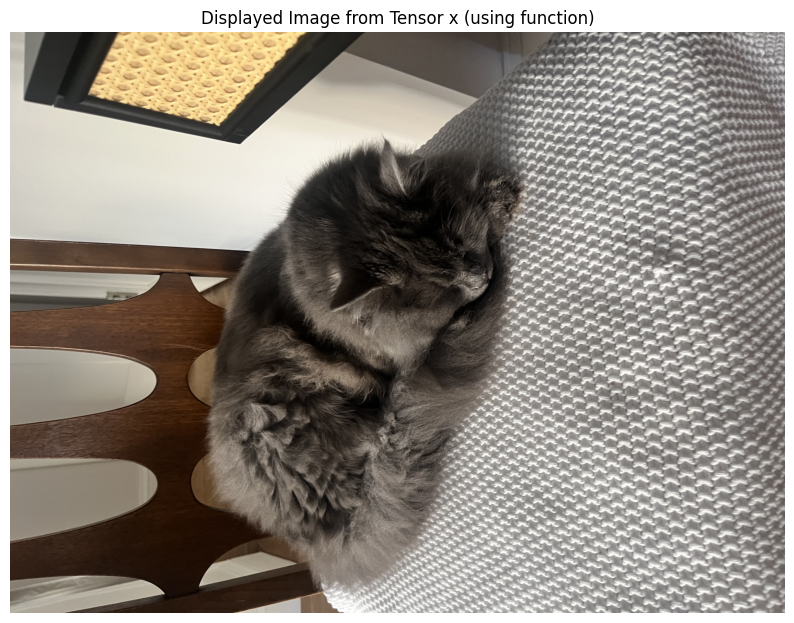

In [10]:
display_image(x)

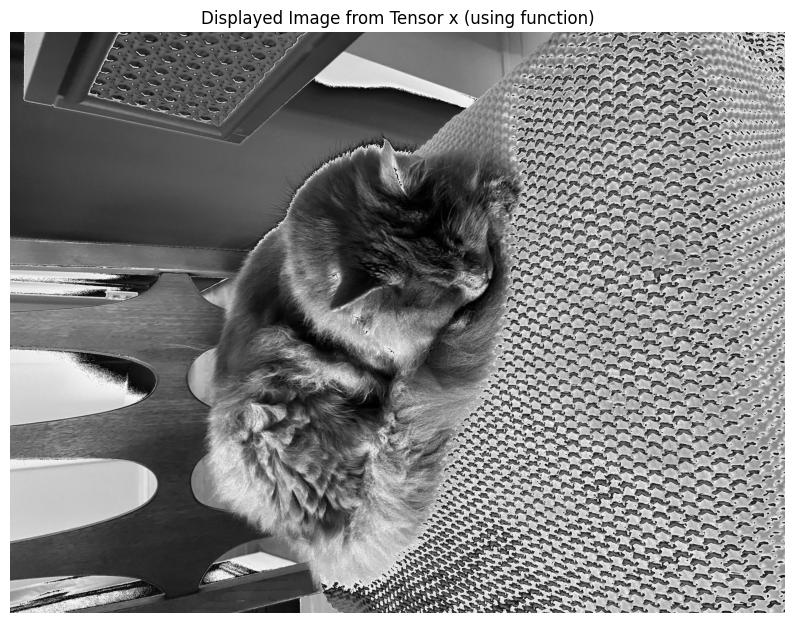

In [11]:
display_image(y)

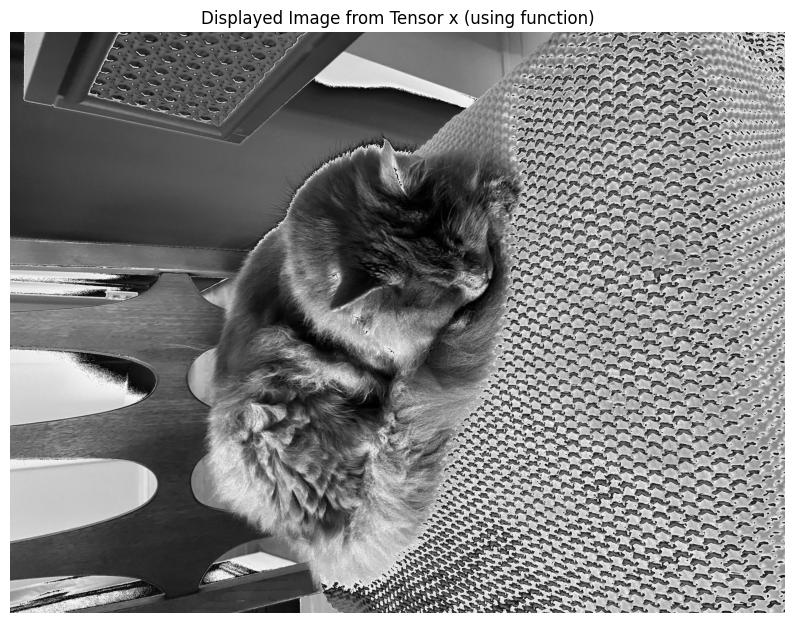

In [12]:
# Demonstrate the new function with the existing 'x' tensor
display_image(y)

### Blur Image

In [43]:
%%writefile blur_image_kernel.cu
#include <c10/cuda/CUDAException.h>
#include <c10/cuda/CUDAStream.h>


__global__
void blur_image_kernel(unsigned char* output, unsigned char* input, int width, int height) {
    const int kRedIndex = 0;
    const int kGreenIndex = 1;
    const int kBlueIndex = 2;

    const int kBlurFactor = 40;


    int col = blockIdx.x * blockDim.x + threadIdx.x;
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    if (col < width && row < height) {
        int totalRed = 0;
        int totalGreen = 0;
        int totalBlue = 0;
        int count = 0;

        for (int i = col - kBlurFactor; i <= col + kBlurFactor; i++) {
          for (int j = row - kBlurFactor; j <= row + kBlurFactor; j++) {
            bool is_col_valid = ((i >= 0) && (i < width));
            bool is_row_valid = ((j >= 0) && (j < height));

            if (!is_col_valid || !is_row_valid) {
              continue;
            }
            count++;
            int inputOffset = 3 * ((j * width) + i);
            totalRed += input[inputOffset + kRedIndex];
            totalGreen += input[inputOffset + kGreenIndex];
            totalBlue += input[inputOffset + kBlueIndex];

            /*if (row == 0 && col == 1) {
              printf("Hello from for loop inside row %u col %u. Count: %u, curr red: %u, totalRed = %u\n", row, col, count, input[inputOffset + kRedIndex], totalRed);
              printf("input offset = %u\n", inputOffset);
            }*/
          }
        }

        int avgRed = totalRed / count;
        int avgGreen = totalGreen / count;
        int avgBlue = totalBlue / count;


        int outputOffset = 3 * (row * width + col);
        output[outputOffset + kRedIndex] = (unsigned char)avgRed;
        output[outputOffset + kGreenIndex] = (unsigned char)avgGreen;
        output[outputOffset + kBlueIndex] = (unsigned char)avgBlue;

        /*if (row == 0 && col == 0) {
          printf("Hello from row %u col %u. Count: %u, totalRed = %u, avgRed = %u\n", row, col, count, totalRed, avgRed);
        }*/

        /*if (row == 0 && col == 1) {
          printf("Hello from row %u col %u. Count: %u, totalRed = %u, avgRed = %u\n", row, col, count, totalRed, avgRed);
          printf("output offset = %u\n", outputOffset);
        }*/

        /*if (row == 4 && col == 4) {
          printf("Hello from row %u col %u. Count: %u, totalRed = %u, avgRed = %u\n", row, col, count, totalRed, avgRed);
        }*/
    }
}


// helper function for ceiling unsigned integer division
inline unsigned int cdiv(unsigned int a, unsigned int b) {
  return (a + b - 1) / b;
}


torch::Tensor blur_image(torch::Tensor image) {
    assert(image.device().type() == torch::kCUDA);
    assert(image.dtype() == torch::kByte);

    const auto height = image.size(0);
    const auto width = image.size(1);

    auto result = torch::empty({height, width, 3}, torch::TensorOptions().dtype(torch::kByte).device(image.device()));

    dim3 threads_per_block(16, 16);     // using 256 threads per block
    dim3 number_of_blocks(cdiv(width, threads_per_block.x),
                          cdiv(height, threads_per_block.y));

    blur_image_kernel<<<number_of_blocks, threads_per_block, 0, torch::cuda::getCurrentCUDAStream()>>>(
        result.data_ptr<unsigned char>(),
        image.data_ptr<unsigned char>(),
        width,
        height
    );

    // check CUDA error status (calls cudaGetLastError())
    C10_CUDA_KERNEL_LAUNCH_CHECK();

    return result;
}

Overwriting blur_image_kernel.cu


In [44]:
kernel_path = "/content/blur_image_kernel.cu"
cpp_source = "torch::Tensor blur_image(torch::Tensor image);"
kernel_name = "blur_image_kernel"
functions = ["blur_image"]

ext = compile_extension(kernel_path, cpp_source, kernel_name, functions)

x = read_image("/content/drive/MyDrive/Pocket.jpeg").permute(1, 2, 0).cuda()
print("mean:", x.float().mean())
print("Input image:", x.shape, x.dtype)

assert x.dtype == torch.uint8

y = ext.blur_image(x)

print("Output image:", y.shape, y.dtype)
print("mean", y.float().mean())
write_png(y.permute(2, 0, 1).cpu(), "output.png")

[1/3] c++ -MMD -MF main.o.d -DTORCH_EXTENSION_NAME=blur_image_kernel_v8 -DTORCH_API_INCLUDE_EXTENSION_H -isystem /usr/local/lib/python3.12/dist-packages/torch/include -isystem /usr/local/lib/python3.12/dist-packages/torch/include/torch/csrc/api/include -isystem /usr/local/cuda/include -isystem /usr/include/python3.12 -fPIC -std=c++17 -c /root/.cache/torch_extensions/py312_cu128/blur_image_kernel/main.cpp -o main.o 
[2/3] /usr/local/cuda/bin/nvcc -MD -MF cuda.cuda.o.d -DTORCH_EXTENSION_NAME=blur_image_kernel_v8 -DTORCH_API_INCLUDE_EXTENSION_H -isystem /usr/local/lib/python3.12/dist-packages/torch/include -isystem /usr/local/lib/python3.12/dist-packages/torch/include/torch/csrc/api/include -isystem /usr/local/cuda/include -isystem /usr/include/python3.12 -D__CUDA_NO_HALF_OPERATORS__ -D__CUDA_NO_HALF_CONVERSIONS__ -D__CUDA_NO_BFLOAT16_CONVERSIONS__ -D__CUDA_NO_HALF2_OPERATORS__ --expt-relaxed-constexpr -gencode=arch=compute_75,code=compute_75 -gencode=arch=compute_75,code=sm_75 --compiler

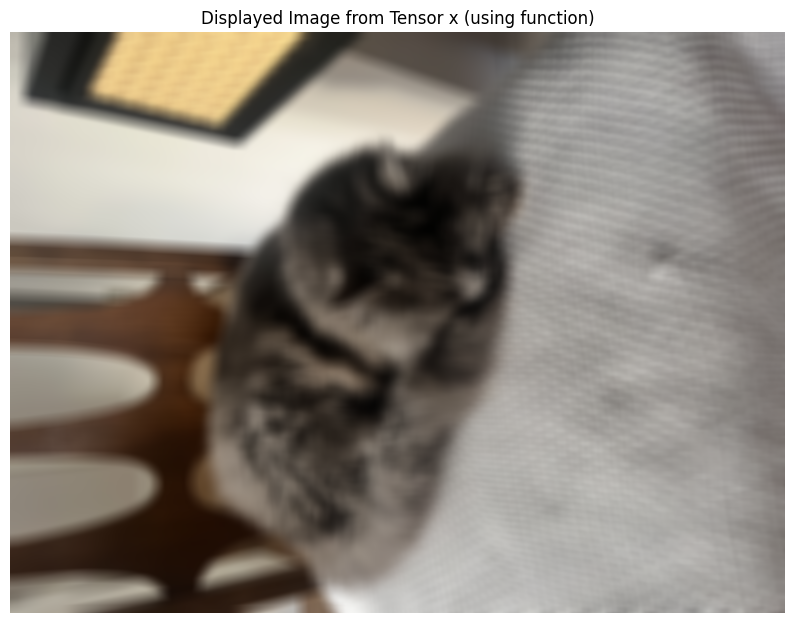

In [45]:
display_image(y)